Epoch: 1 Error: 1
Epoch: 2 Error: 0

Final weights:
w1 = 1.0
w2 = 1.0
b  = -1.0

Testing:
Input: -1 -1 Output: -1
Input: -1 1 Output: -1
Input: 1 -1 Output: -1
Input: 1 1 Output: 1


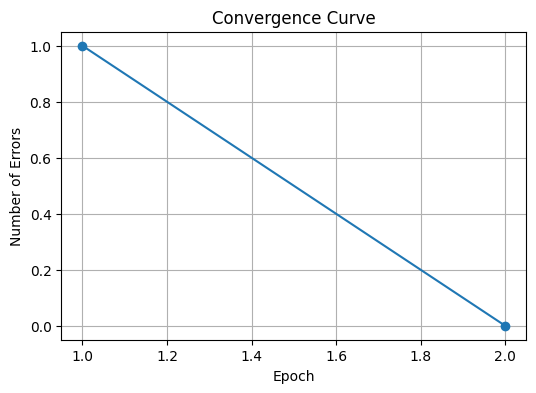

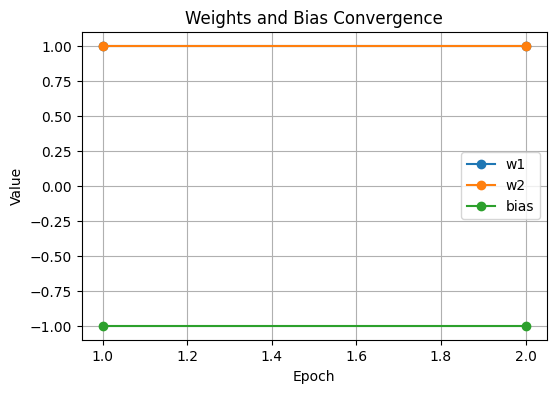

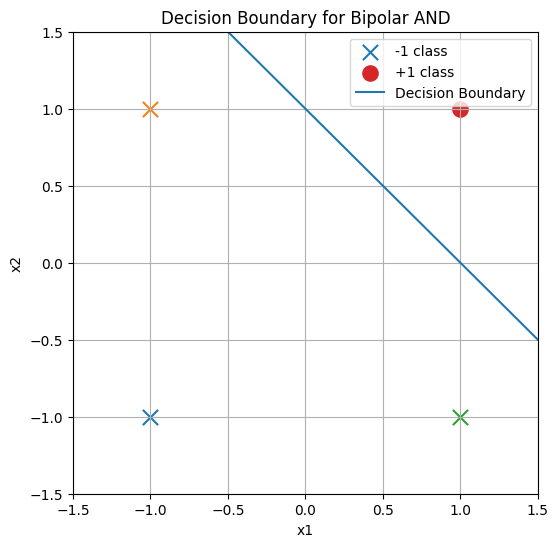

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Bipolar AND inputs
X = np.array([
    [-1, -1],
    [-1,  1],
    [ 1, -1],
    [ 1,  1]
])

# Bipolar AND targets
T = np.array([-1, -1, -1, 1])

# Initial weights and bias
w1 = 0
w2 = 0
b = 0

# Learning rate
lr = 0.5

# For graphs
errors_list = []
w1_list = []
w2_list = []
b_list = []

# Activation function
def output(net):
    if net >= 0:
        return 1
    else:
        return -1

# Training
for epoch in range(10):
    error = 0
    
    for i in range(len(X)):
        x1 = X[i][0]
        x2 = X[i][1]
        target = T[i]
        
        net = w1*x1 + w2*x2 + b
        y = output(net)
        
        if y != target:
            change = lr * (target - y)
            
            w1 = w1 + change*x1
            w2 = w2 + change*x2
            b = b + change
            
            error += 1
    
    errors_list.append(error)
    w1_list.append(w1)
    w2_list.append(w2)
    b_list.append(b)
    
    print("Epoch:", epoch + 1, "Error:", error)
    
    if error == 0:
        break

# Final result
print("\nFinal weights:")
print("w1 =", w1)
print("w2 =", w2)
print("b  =", b)

print("\nTesting:")
for i in range(len(X)):
    x1 = X[i][0]
    x2 = X[i][1]
    
    net = w1*x1 + w2*x2 + b
    y = output(net)
    
    print("Input:", x1, x2, "Output:", y)


# -------------------------------
# 1. Convergence Curve: Error
# -------------------------------
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(errors_list) + 1), errors_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.title("Convergence Curve")
plt.grid(True)
plt.show()


# -----------------------------------------
# 2. Convergence Curve: Weights and Bias
# -----------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(w1_list) + 1), w1_list, marker='o', label="w1")
plt.plot(range(1, len(w2_list) + 1), w2_list, marker='o', label="w2")
plt.plot(range(1, len(b_list) + 1), b_list, marker='o', label="bias")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Weights and Bias Convergence")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------
# 3. Decision Boundary Line
# -------------------------------
plt.figure(figsize=(6, 6))

# Plot data points
for i in range(len(X)):
    if T[i] == 1:
        plt.scatter(X[i][0], X[i][1], marker='o', s=120, label="+1 class" if i == 3 else "")
    else:
        plt.scatter(X[i][0], X[i][1], marker='x', s=120, label="-1 class" if i == 0 else "")

# Decision boundary:
# w1*x1 + w2*x2 + b = 0
# x2 = -(w1*x1 + b) / w2

x_values = np.linspace(-1.5, 1.5, 100)

if w2 != 0:
    y_values = -(w1*x_values + b) / w2
    plt.plot(x_values, y_values, label="Decision Boundary")
else:
    x_vertical = -b / w1
    plt.axvline(x_vertical, label="Decision Boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary for Bipolar AND")
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
plt.show()